# SAC-Discrete + FHR on CartPole

SAC-Discrete (`agents/sb3_sac_fhr.SACD`: categorical actor, twin Q(s,·) critics, exact expectations, auto-tuned temperature) with the FHR recurrence penalty on both critics — fixed global c, state-conditioned c(s,a), and a prioritized-replay arm. The λ=0 baseline arm is the SACD reference (bit-exact vs plain SACD by `tests/test_sb3_sac_fhr.py`); the actor's KL(π‖exp(Q/α)) step consumes the regularised critics implicitly.

Arms, colours and grouping all derive from `configs/config_sb3_sacd.yaml` + the manifest — nothing is hardcoded here.

## 0 · Launch — train whatever the config defines

In [1]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parent / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner
import yaml

CONFIG = "configs/config_sb3_sacd.yaml"
# Every arm below — launched and analysed — is exactly what the config's
# experiment.fhr_experiments block currently defines; nothing is hardcoded.
EXPERIMENTS = sorted(int(k) for k in
                     (yaml.safe_load(open(CONFIG))["experiment"]
                      .get("fhr_experiments") or {}))
print("config experiments:", EXPERIMENTS)

LAUNCH = False
FORCE_EXP = False
if LAUNCH:
    manifest = runner.launch_all(config=CONFIG, experiments=EXPERIMENTS,
                                 max_workers=4, force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False — analysing existing runs only")

config experiments: [1, 2, 3, 4, 5]
LAUNCH = False — analysing existing runs only


In [2]:
import csv, json
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO = pathlib.Path.cwd().parents[2]
sys.path.insert(0, str(REPO / "src"))

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
CFG = yaml.safe_load(open(CONFIG))
CMAN = json.load(open("cached/sb3_runs_manifest_sacd.json"))
SEEDS = [str(s) for s in (CFG["experiment"].get("seeds")
                          or [CFG["experiment"]["seed"]])]

# ---- arms are DERIVED from the config, never hardcoded -------------------
PALETTE = ["tab:green", "tab:blue", "tab:orange", "tab:purple", "tab:red",
           "tab:cyan", "peru", "orchid", "crimson", "tab:olive"]
KIND_ORDER = {"baseline": 0, "global": 1, "ar": 2, "per": 3}

def _spec(n, ov):
    lam = float(ov.get("fhr_weight", CFG["agent"]["fhr_weight"]))
    pred = ov.get("c_predictor")
    per = bool(ov.get("prioritized_replay", False))
    if per:
        kind, name = "per", "FHR + PER"
    elif pred is None:
        kind, name = "global", "standard FHR (global c)"
    else:
        kind, name = "ar", f"{pred} c(s,a)"
    return {"arm": f"exp{n}", "kind": kind, "lam": lam, "pred": pred,
            "label": f"{name} · λ{lam:g}"}

specs = [{"arm": "baseline", "kind": "baseline", "lam": 0.0, "pred": None,
          "label": "baseline (soft TD only)"}]
unrun = []
for n, ov in sorted((int(k), v) for k, v in
                    (CFG["experiment"].get("fhr_experiments") or {}).items()):
    s = _spec(n, ov)
    (specs if CMAN["runs"].get(s["arm"]) else unrun).append(s)
specs.sort(key=lambda s: (KIND_ORDER[s["kind"]], s["lam"], s["pred"] or ""))
if unrun:
    print("defined but not yet run:", [s["arm"] for s in unrun])

ARMS, INFO = {}, {}
for i, s in enumerate(specs):
    label = s["label"]
    if label in ARMS:
        label = f"{label} [{s['arm']}]"
    s["colour"] = "black" if s["kind"] == "baseline" else \
                  PALETTE[(i - 1) % len(PALETTE)]
    ARMS[label] = (s["arm"], s["colour"])
    INFO[label] = s

def labels_of(*kinds):
    return [l for l in ARMS if INFO[l]["kind"] in kinds]

BASE = "baseline (soft TD only)" if "baseline (soft TD only)" in ARMS else None
GLOBALS_ = labels_of("global")
VARIANTS = labels_of("ar")
PER_ARMS = labels_of("per")

def run_dirs(arm):
    out = []
    for s in SEEDS:
        rel = CMAN["runs"].get(arm, {}).get(s)
        if rel and (pathlib.Path(rel) / "rewards.csv").exists():
            out.append((s, pathlib.Path(rel)))
    return out

def curves(arm, fname="eval.csv", x="env_steps", y="mean_reward"):
    cs = []
    for s, d in run_dirs(arm):
        if not (d / fname).exists():
            continue
        rows = list(csv.DictReader(open(d / fname)))
        if rows:
            cs.append((s, np.array([float(r[x]) for r in rows]),
                       np.array([float(r[y]) for r in rows])))
    return cs

def diag(arm, col):
    return curves(arm, fname="train_diagnostics.csv", x="episode", y=col)

print({l: ARMS[l][0] for l in ARMS})

{'baseline (soft TD only)': 'baseline', 'standard FHR (global c) · λ0.5': 'exp1', 'standard FHR (global c) · λ1': 'exp2', 'separate c(s,a) · λ0.5': 'exp4', 'shared c(s,a) · λ0.5': 'exp3', 'FHR + PER · λ0.5': 'exp5'}


## 1 · Learning curves — the main result

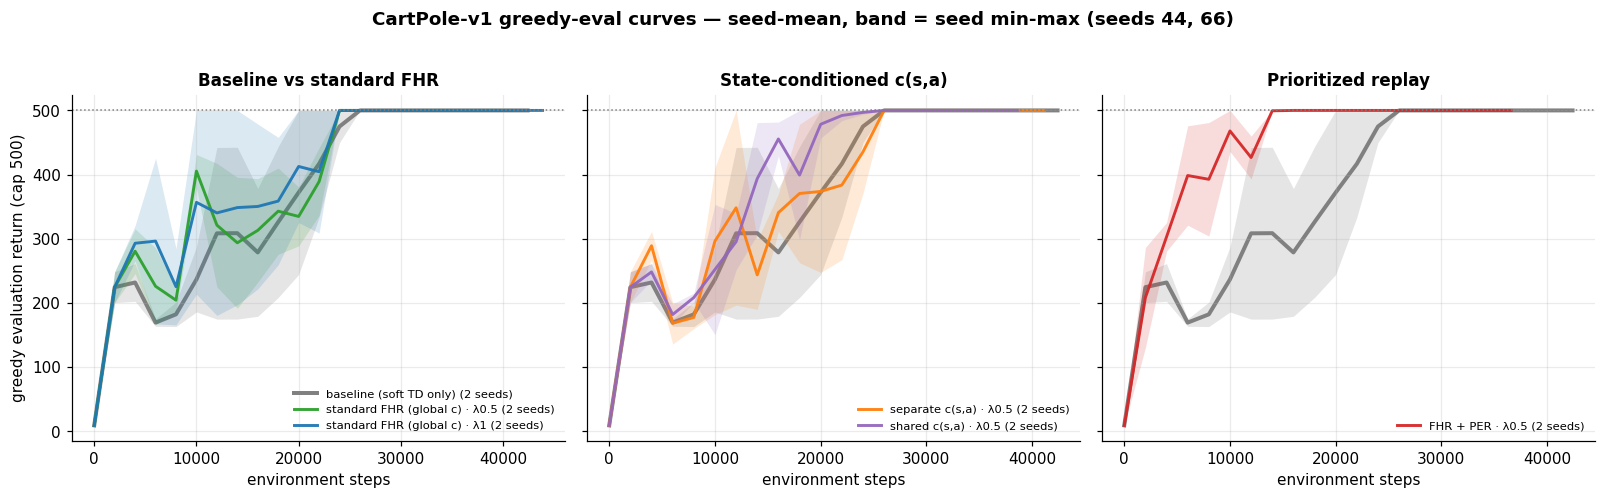

In [3]:
GROUP_DEFS = [("Baseline vs standard FHR", ("baseline", "global")),
              ("State-conditioned c(s,a)", ("ar",)),
              ("Prioritized replay", ("per",))]
GROUPS = [(t, labels_of(*kinds)) for t, kinds in GROUP_DEFS]
GROUPS = [(t, ls) for t, ls in GROUPS if ls]

def seed_band(ax, label, colr=None, lw=1.9, alpha=0.95, band_alpha=0.16,
              legend=True, zorder=2, **kw):
    cs = curves(ARMS[label][0], **kw)
    if not cs:
        return
    n = min(len(y) for _, _, y in cs)
    x, Y = cs[0][1][:n], np.stack([y[:n] for _, _, y in cs])
    colr = colr or ARMS[label][1]
    if len(cs) > 1:
        ax.fill_between(x, Y.min(0), Y.max(0), color=colr, alpha=band_alpha,
                        lw=0, zorder=zorder - 1)
    ax.plot(x, Y.mean(0), lw=lw, color=colr, alpha=alpha, zorder=zorder,
            label=f"{label} ({len(cs)} seeds)" if legend else None)

fig, axes = plt.subplots(1, len(GROUPS), figsize=(4.9 * len(GROUPS), 4.4),
                         sharey=True, squeeze=False)
for ax, (title, labels) in zip(axes.ravel(), GROUPS):
    if BASE:
        seed_band(ax, BASE, "gray", lw=2.6, alpha=1.0, band_alpha=0.20,
                  legend=BASE in labels, zorder=1)
    for label in labels:
        if label == BASE:
            continue
        seed_band(ax, label)
    ax.axhline(500, color="gray", ls=":", lw=1)
    ax.set(title=title, xlabel="environment steps")
    ax.legend(fontsize=7.5, loc="lower right")
axes[0, 0].set_ylabel("greedy evaluation return (cap 500)")
fig.suptitle(f"{CFG['environment']['name']} greedy-eval curves — seed-mean, "
             f"band = seed min-max (seeds {', '.join(SEEDS)})",
             fontweight="bold", y=1.02)
plt.tight_layout()

## 2 · Final performance

baseline (soft TD only)                        500.0   [500.0, 500.0]
standard FHR (global c) · λ0.5                 500.0   [500.0, 500.0]
standard FHR (global c) · λ1                   500.0   [500.0, 500.0]
separate c(s,a) · λ0.5                         500.0   [500.0, 500.0]
shared c(s,a) · λ0.5                           500.0   [500.0, 500.0]
FHR + PER · λ0.5                               500.0   [500.0, 500.0]


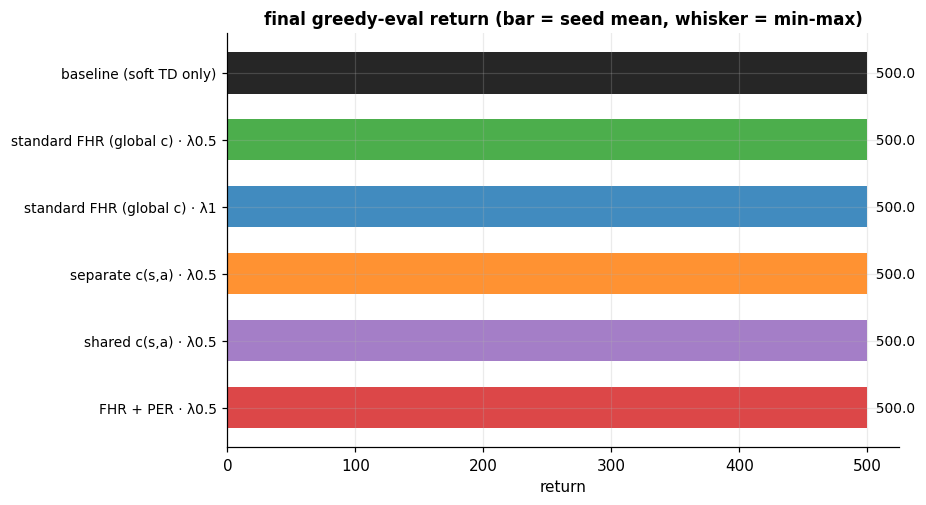

In [4]:
# Final greedy-eval performance per arm (last eval.csv row, mean over seeds)
rows = []
for label in ARMS:
    cs = curves(ARMS[label][0])
    if cs:
        finals = [y[-1] for _, _, y in cs]
        rows.append((label, np.mean(finals), np.min(finals), np.max(finals),
                     ARMS[label][1]))
fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(rows) + 1.4))
ypos = np.arange(len(rows))[::-1]
for y, (label, mean, lo, hi, colr) in zip(ypos, rows):
    ax.barh(y, mean, color=colr, alpha=0.85, height=0.62)
    ax.plot([lo, hi], [y, y], color="black", lw=1.4)
    ax.text(mean, y, f"  {mean:.1f}", va="center", fontsize=9)
ax.set_yticks(ypos, [r[0] for r in rows], fontsize=9)
ax.set(title="final greedy-eval return (bar = seed mean, whisker = min-max)",
       xlabel="return")
plt.tight_layout()
for label, mean, lo, hi, _ in rows:
    print(f"{label:42s} {mean:9.1f}   [{lo:.1f}, {hi:.1f}]")

## 3 · FHR + SAC internals

Penalty, coefficients, temperature and actor loss per training burst (`train_diagnostics.csv`).

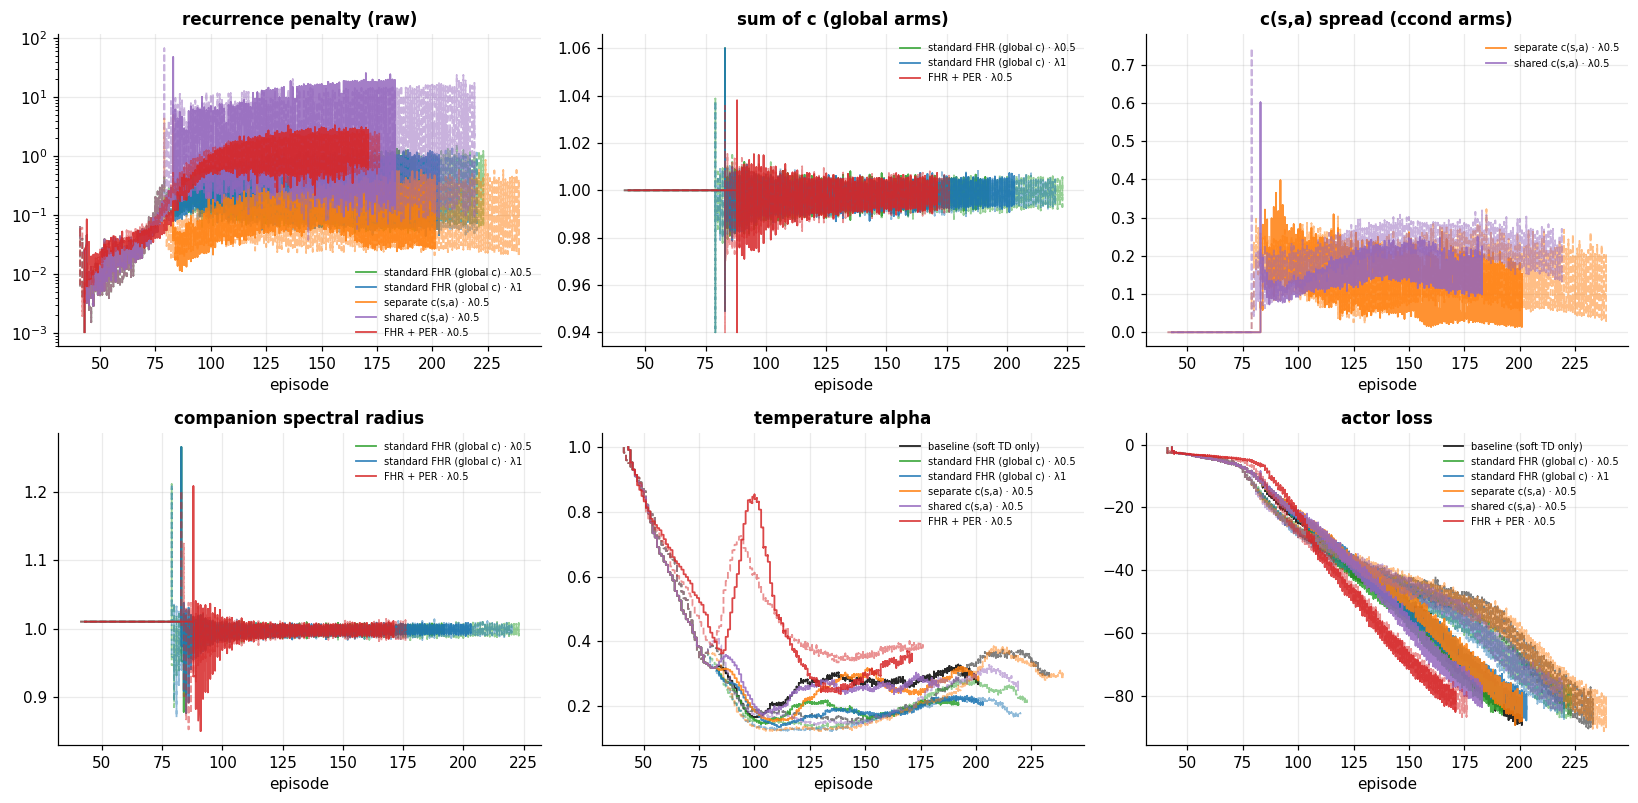

In [5]:
# FHR/SAC internals per gradient-burst row: the recurrence penalty, the
# learned coefficients, the temperature and the actor loss.
panels = [("penalty_raw", "recurrence penalty (raw)", labels_of("global", "ar", "per")),
          ("sum_c", "sum of c (global arms)", GLOBALS_ + PER_ARMS),
          ("c_spread", "c(s,a) spread (ccond arms)", VARIANTS),
          ("companion_radius", "companion spectral radius", GLOBALS_ + PER_ARMS),
          ("ent_coef", "temperature alpha", list(ARMS)),
          ("actor_loss", "actor loss", list(ARMS))]
panels = [(c, t, ls) for c, t, ls in panels if ls]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4))
for ax, (col, title, labels) in zip(axes.ravel(), panels):
    for label in labels:
        for s, x, y in diag(ARMS[label][0], col):
            m = np.isfinite(y)
            if m.any():
                ax.plot(x[m], y[m], lw=1.2, color=ARMS[label][1],
                        alpha=0.85 if s == SEEDS[0] else 0.5,
                        ls="-" if s == SEEDS[0] else "--",
                        label=label if s == SEEDS[0] else None)
    ax.set(title=title, xlabel="episode")
    if col in ("penalty_raw",):
        ax.set_yscale("log")
    ax.legend(fontsize=6.5)
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
plt.tight_layout()

## 4 · Hankel low-rankness of the value trajectory

The claim under test: the greedy rollout's Q sequence obeys a low-order linear recurrence — FHR arms should concentrate the Hankel spectrum faster than the baseline.

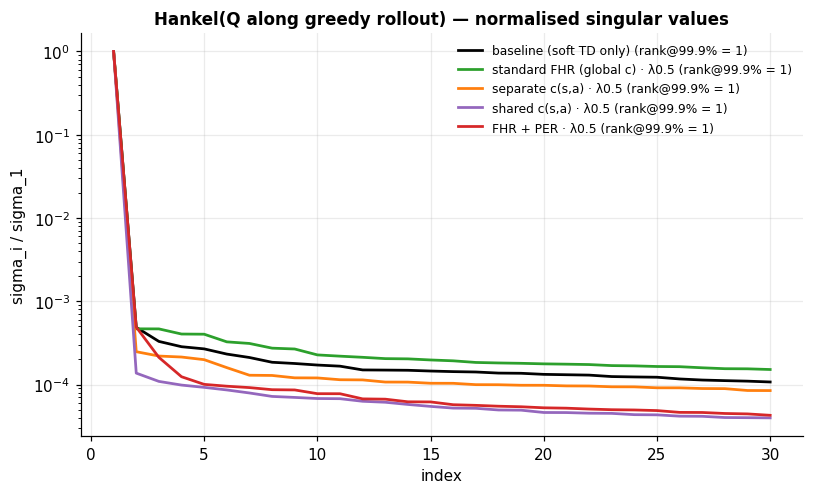

In [6]:
# Hankel low-rankness of the greedy value trajectory, per arm: roll the
# trained policy, Hankel the min-twin Q(s_t, a_t) sequence, compare spectra.
import gymnasium as gym
from analysis.low_rank.hankel_policy import (_hankel_from_sequence,
                                             collect_hankel_sequences)
from analysis.low_rank.rank import energy_rank

SHOW = [l for l in ([BASE] + GLOBALS_[:1] + VARIANTS + PER_ARMS[:1]) if l]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for label in SHOW:
    arm = ARMS[label][0]
    dirs = run_dirs(arm)
    if not dirs:
        continue
    _, adapter = runner.load_run_model(dirs[0][1], device="cpu")
    adapter.epsilon = 0.0
    env = runner._make_env(CFG)
    spectra = []
    for k in range(3):
        seqs = collect_hankel_sequences(adapter, env, seed=52 + k)
        H = _hankel_from_sequence(seqs["Hankel Q"])
        sv = np.linalg.svd(H, compute_uv=False)
        spectra.append(sv / sv[0])
    env.close()
    n = min(len(s) for s in spectra)
    S = np.stack([s[:n] for s in spectra]).mean(0)
    r = energy_rank(S, 0.999)
    ax.semilogy(np.arange(1, min(len(S), 30) + 1), S[:30], lw=1.8,
                color=ARMS[label][1], label=f"{label} (rank@99.9% = {r})")
ax.set(title="Hankel(Q along greedy rollout) — normalised singular values",
       xlabel="index", ylabel="sigma_i / sigma_1")
ax.legend(fontsize=8)
plt.tight_layout()

## 5 · Findings

*(fill in after the sweep completes)*